### Importing Libraries 

In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

### Connecting to My Azure Database 

### Loading the table views created in MySQL database  

In [9]:
performance = pd.read_sql(
    "SELECT * FROM vw_student_performance",
    engine
)

attendance = pd.read_sql(
    "SELECT * FROM vw_attendance_summary",
    engine
)

### inspection of the data 

In [7]:
attendance.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Student_ID           168 non-null    str  
 1   Student_Name         168 non-null    str  
 2   Term_ID              168 non-null    int64
 3   Term_Name            168 non-null    str  
 4   Attendance           168 non-null    int64
 5   Attendance_Category  168 non-null    str  
dtypes: int64(2), str(4)
memory usage: 8.0 KB


### Data Quality Assessment 

In [9]:
performance.shape

(158, 15)

In [10]:
attendance.shape

(168, 6)

In [11]:
performance.isnull().sum()

Student_ID                   0
Student_Name                 0
Term_ID                      0
Term_Name                    0
English                      0
Mathematics                  0
Integrated_Science           0
Computing                    0
Career_Technology            0
Creative_Arts                0
French                       0
Ghanaian_Language            0
Religious_Moral_Education    0
Social_Studies               0
Overall_Average              0
dtype: int64

In [13]:
attendance.isnull().sum()

Student_ID             0
Student_Name           0
Term_ID                0
Term_Name              0
Attendance             0
Attendance_Category    0
dtype: int64

In [14]:
performance.duplicated().sum()

np.int64(0)

In [15]:
attendance.duplicated().sum()

np.int64(0)

In [16]:
performance.describe()

,Term_ID,English,Mathematics,Integrated_Science,Computing,Career_Technology,Creative_Arts,French,Ghanaian_Language,Religious_Moral_Education,Social_Studies,Overall_Average
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.00000
mean,1.993671,55.686709,42.373418,52.547468,46.876582,49.218354,53.098101,49.322785,44.832278,59.455696,56.838608,51.02500
std,0.817771,8.446249,14.254727,9.002085,11.387736,11.945395,8.140185,13.093013,12.861661,11.980927,11.083825,8.16625
min,1.000000,36.500000,12.500000,36.000000,15.000000,22.500000,37.000000,18.500000,18.500000,23.000000,30.000000,34.60000
25%,1.000000,50.000000,32.125000,46.500000,39.000000,41.625000,47.500000,39.750000,35.500000,53.000000,49.750000,46.20000
50%,2.000000,54.500000,42.250000,51.750000,47.500000,48.000000,53.000000,48.000000,43.750000,60.000000,57.750000,50.82500
75%,3.000000,60.000000,51.875000,57.500000,54.875000,56.500000,57.500000,58.000000,53.500000,67.500000,63.375000,55.47500
max,3.000000,81.000000,86.500000,88.500000,76.500000,84.000000,84.000000,87.500000,75.000000,85.500000,81.500000,73.50000


In [17]:
attendance.describe()

,Term_ID,Attendance
count,168.000000,168.000000
mean,1.970238,59.583333
std,0.814727,7.956029
min,1.000000,33.000000
25%,1.000000,54.000000
50%,2.000000,62.000000
75%,3.000000,67.000000
max,3.000000,69.000000


## EXPLORATORY DATA ANALYSIS

### Descriptive Statistics
We begin by generating summary statistics for both the student performance and attendance datasets. These statistics provide an overview of the data distribution, including measures such as the mean, standard deviation, minimum, maximum, and quartiles. This helps us understand the overall characteristics of the dataset before performing more detailed analyses.

In [18]:
performance.describe().T

,count,mean,std,min,25%,50%,75%,max
Term_ID,158.0,1.993671,0.817771,1.0,1.000,2.000,3.000,3.0
English,158.0,55.686709,8.446249,36.5,50.000,54.500,60.000,81.0
Mathematics,158.0,42.373418,14.254727,12.5,32.125,42.250,51.875,86.5
Integrated_Science,158.0,52.547468,9.002085,36.0,46.500,51.750,57.500,88.5
Computing,158.0,46.876582,11.387736,15.0,39.000,47.500,54.875,76.5
Career_Technology,158.0,49.218354,11.945395,22.5,41.625,48.000,56.500,84.0
Creative_Arts,158.0,53.098101,8.140185,37.0,47.500,53.000,57.500,84.0
French,158.0,49.322785,13.093013,18.5,39.750,48.000,58.000,87.5
Ghanaian_Language,158.0,44.832278,12.861661,18.5,35.500,43.750,53.500,75.0
Religious_Moral_Education,158.0,59.455696,11.980927,23.0,53.000,60.000,67.500,85.5


In [19]:
attendance.describe().T

,count,mean,std,min,25%,50%,75%,max
Term_ID,168.0,1.970238,0.814727,1.0,1.0,2.0,3.0,3.0
Attendance,168.0,59.583333,7.956029,33.0,54.0,62.0,67.0,69.0


### Interpretation

The descriptive statistics provide an overview of students' academic performance and attendance across the three academic terms.

The average overall academic score is **51.03%**, indicating that, on average, students achieved just above the minimum passing level. Student performance ranges from **34.6%** to **73.5%**, suggesting noticeable variation in academic achievement across the cohort.

Among the core subjects, **Social Studies (56.84%)**, **English (55.69%)**, and **Integrated Science (52.55%)** recorded the highest average scores, while **Ghanaian Language (44.83%)** and **French (49.32%)** had comparatively lower average performance.

Attendance statistics show an average attendance of **59.58** out of a maximum of **69**, indicating generally good student attendance throughout the academic year. The relatively small standard deviation suggests that attendance levels were fairly consistent among students.

## Distribution of Overall Academic Performance

A histogram is used to visualize the distribution of students' overall academic averages. This helps determine whether performance is concentrated around specific score ranges, identify any skewness in the distribution, and detect potential outliers.

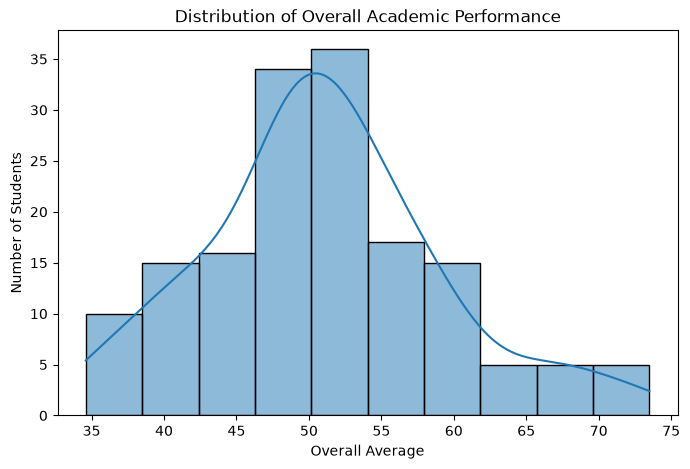

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=performance,
    x="Overall_Average",
    bins=10,
    kde=True
)

plt.title("Distribution of Overall Academic Performance")
plt.xlabel("Overall Average")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The histogram shows that students' overall academic performance is concentrated around the **45% to 55%** range, with the highest frequency occurring near **50%**. This indicates that the majority of students achieved average academic performance during the academic year.

Only a small number of students scored above **65%**, while relatively few students obtained scores below **40%**. The distribution is approximately bell-shaped with a slight positive skew, suggesting that exceptionally high-performing students are less common than students with average performance.

Overall, the results indicate that most students are performing at a moderate level, highlighting opportunities for targeted interventions to improve academic achievement and increase the proportion of high-performing students.

### Average Academic Performance by Academic Term

This visualization compares the average overall academic performance across the three academic terms. Since overall performance is expressed as a percentage, it provides a standardized basis for evaluating whether students' academic achievement improved, declined, or remained consistent throughout the academic year.

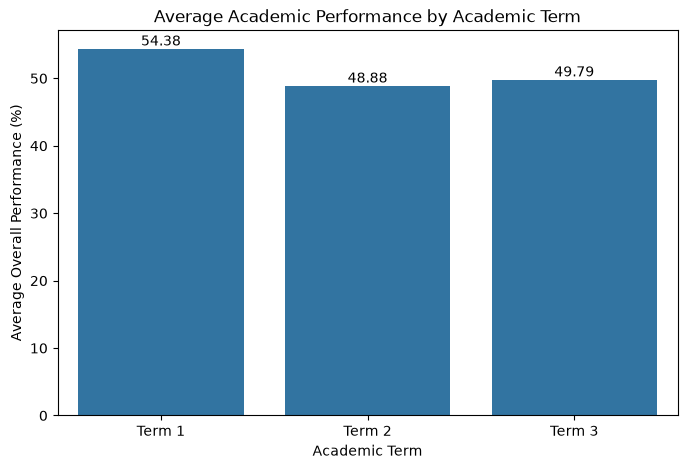

In [13]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=performance,
    x="Term_Name",
    y="Overall_Average",
    estimator="mean",
    errorbar=None,
    order=["Term 1", "Term 2", "Term 3"]
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Academic Performance by Academic Term")
plt.xlabel("Academic Term")
plt.ylabel("Average Overall Performance (%)")

plt.show()

### Interpretation

The chart shows that students achieved the highest average academic performance in **Term 1 (54.38%)**. Average performance declined to **48.88%** in **Term 2**, representing the lowest level recorded during the academic year. In **Term 3**, performance improved slightly to **49.79%**, although it remained below the level achieved in Term 1.

Overall, the results indicate that student academic performance declined after the first term, with only a modest recovery in the final term. This trend suggests that factors affecting student achievement may have emerged after Term 1 and could warrant further investigation.

### Distribution of Academic Performance Across Terms

While the previous visualization compared the average academic performance across the three terms, averages alone do not reveal how individual student scores are distributed. A box plot provides a more comprehensive view by displaying the median, quartiles, overall spread of the data, and any potential outliers. This helps assess the consistency of student performance within each academic term.

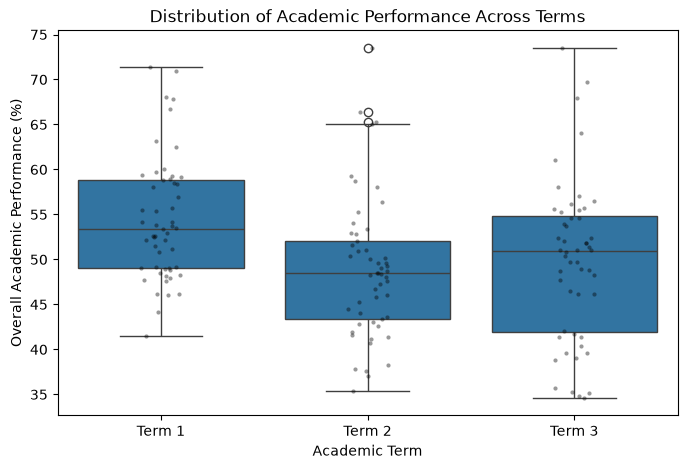

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=performance,
    x="Term_Name",
    y="Overall_Average",
    order=["Term 1", "Term 2", "Term 3"]
)

sns.stripplot(
    data=performance,
    x="Term_Name",
    y="Overall_Average",
    order=["Term 1", "Term 2", "Term 3"],
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of Academic Performance Across Terms")
plt.xlabel("Academic Term")
plt.ylabel("Overall Academic Performance (%)")

plt.show()

### Interpretation

The box plot provides a detailed comparison of student performance across the three academic terms. Consistent with the previous analysis, **Term 1 recorded the highest median academic performance**, while **Term 2 exhibited the lowest median**, indicating a decline in students' overall achievement after the first term. **Term 3 showed a modest improvement**, although the median remained below that of Term 1.

The interquartile ranges are relatively similar across all three terms, suggesting that the variability in student performance remained fairly consistent throughout the academic year. However, **Term 2 contains several high-performing outliers**, indicating that despite the overall decline in performance, a small number of students continued to achieve exceptionally high scores.

Overall, the results suggest that changes in average academic performance across the terms were driven primarily by shifts in the performance of the majority of students rather than by increased variation within the cohort.

### Average Performance by Subject

This analysis compares the average student score across all subjects. By examining subject-level performance, we can identify the strongest and weakest performing subjects and determine where students demonstrated the highest and lowest levels of achievement.

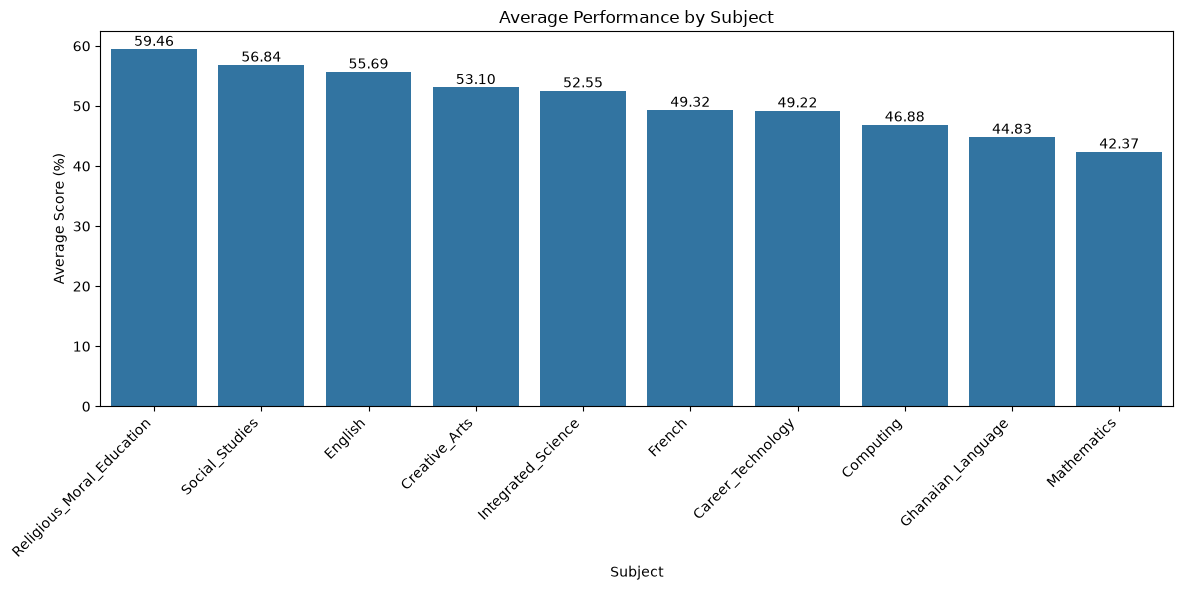

In [16]:
subject_means = (
    performance[
        [
            "English",
            "Mathematics",
            "Integrated_Science",
            "Computing",
            "Creative_Arts",
            "Career_Technology",
            "French",
            "Ghanaian_Language",
            "Religious_Moral_Education",
            "Social_Studies",
        ]
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=subject_means.index,
    y=subject_means.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.xticks(rotation=45, ha="right")
plt.title("Average Performance by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score (%)")

plt.tight_layout()
plt.show()

### Interpretation

The chart compares the average performance across all subjects over the three academic terms, providing an overall view of students' academic strengths and weaknesses. **Religious and Moral Education** recorded the highest average score (**59.46%**), followed by **Social Studies (56.84%)** and **English (55.69%)**, indicating that students generally performed better in these subjects throughout the academic year.

Conversely, **Mathematics** recorded the lowest average score (**42.37%**), followed by **Ghanaian Language (44.83%)** and **Computing (46.88%)**. These results suggest that students experienced greater academic challenges in these subjects compared to the others.

Overall, the average subject scores ranged from **42.37%** to **59.46%**, representing a difference of approximately **17 percentage points** between the highest- and lowest-performing subjects. This variation indicates that student achievement was not uniform across the curriculum, with some subjects consistently producing stronger academic outcomes than others.

## Subject Performance Across Academic Terms

While the previous chart compared the overall average performance for each subject across the academic year, this analysis examines how subject performance changed from one academic term to another. Comparing subjects across terms helps identify trends, such as subjects that consistently performed well, subjects that improved over time, and subjects that experienced declining performance.

In [17]:
subject_by_term = performance.melt(
    id_vars=["Term_Name"],
    value_vars=[
        "English",
        "Mathematics",
        "Integrated_Science",
        "Computing",
        "Creative_Arts",
        "Career_Technology",
        "French",
        "Ghanaian_Language",
        "Religious_Moral_Education",
        "Social_Studies"
    ],
    var_name="Subject",
    value_name="Score"
)

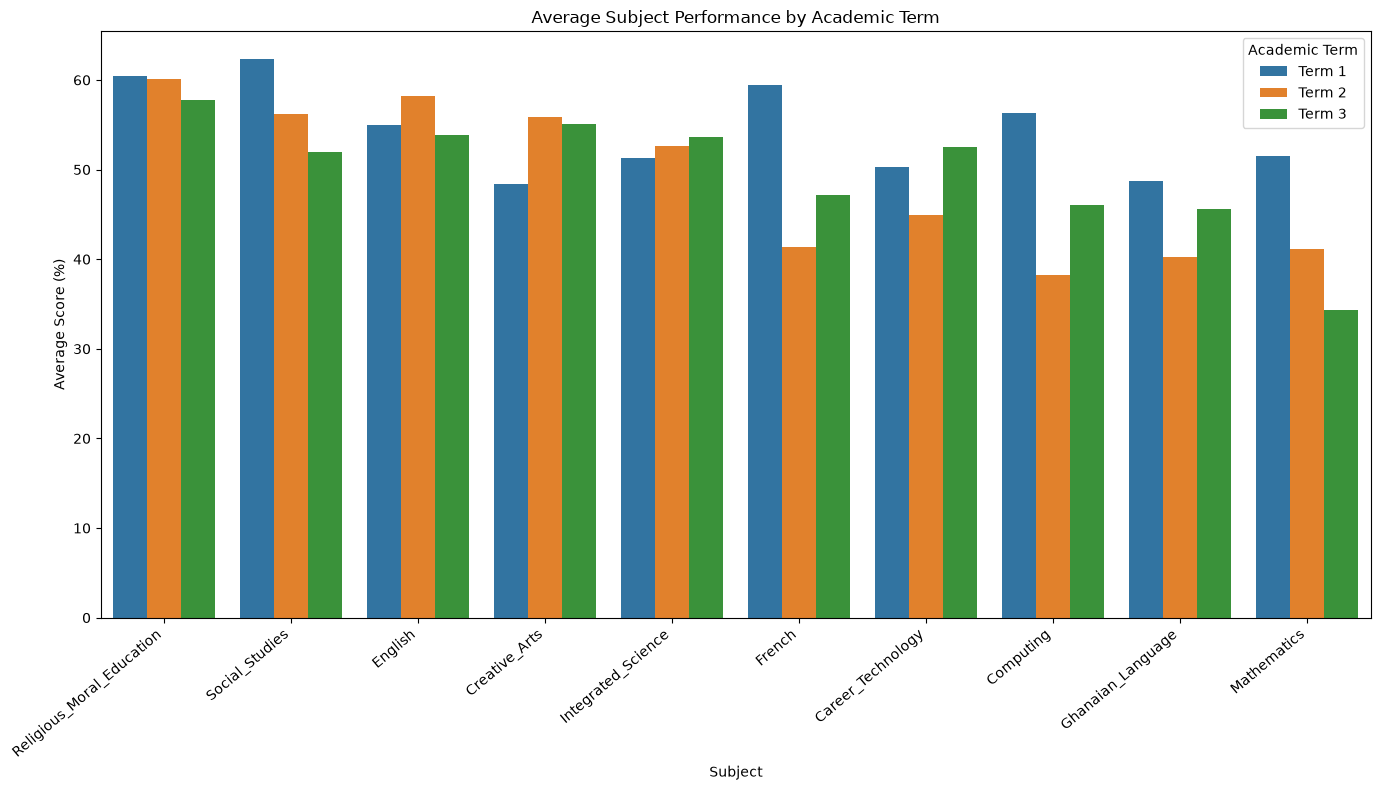

In [19]:
plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=subject_by_term,
    x="Subject",
    y="Score",
    hue="Term_Name",
    estimator="mean",
    errorbar=None,
    order=[
        "Religious_Moral_Education",
        "Social_Studies",
        "English",
        "Creative_Arts",
        "Integrated_Science",
        "French",
        "Career_Technology",
        "Computing",
        "Ghanaian_Language",
        "Mathematics"
    ],
    hue_order=["Term 1", "Term 2", "Term 3"]
)

plt.title("Average Subject Performance by Academic Term")
plt.xlabel("Subject")
plt.ylabel("Average Score (%)")

plt.xticks(rotation=40, ha="right")

plt.legend(title="Academic Term")

plt.tight_layout()

plt.show()

### Interpretation

The grouped bar chart compares average student performance across all subjects for each academic term, providing insight into how subject-level achievement changed throughout the academic year.

Overall, **Religious and Moral Education**, **Social Studies**, and **English** consistently recorded the highest average scores across the three terms, demonstrating relatively strong student performance in these subjects. In contrast, **Mathematics** remained the lowest-performing subject throughout the academic year, while **French**, **Computing**, and **Ghanaian Language** also recorded comparatively lower average scores.

The chart further reveals that subject performance did not change uniformly over time. While subjects such as **Career Technology** and **Integrated Science** remained relatively stable or showed modest improvement, several subjects—including **Mathematics**, **Computing**, and **French**—experienced noticeable declines after Term 1. These differences suggest that the overall decline in academic performance observed earlier was driven more by changes in specific subjects than by a uniform decline across the entire curriculum.

### Distribution of Student Performance by Subject

While the previous analyses focused on average subject performance and changes across academic terms, they do not reveal how student scores are distributed within each subject. A box plot summarizes the distribution of scores by displaying the median, quartiles, spread, and potential outliers for each subject. This helps identify subjects with consistent performance as well as those with greater variability among students.

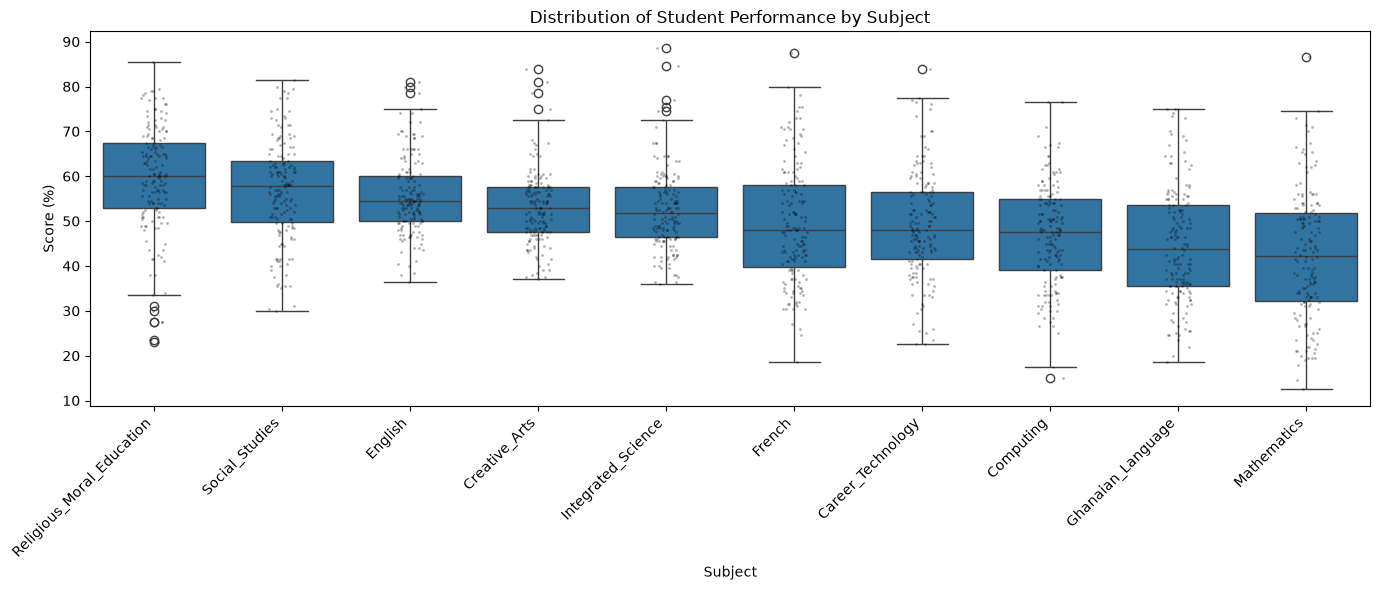

In [20]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=subject_by_term,
    x="Subject",
    y="Score",
    order=[
        "Religious_Moral_Education",
        "Social_Studies",
        "English",
        "Creative_Arts",
        "Integrated_Science",
        "French",
        "Career_Technology",
        "Computing",
        "Ghanaian_Language",
        "Mathematics"
    ]
)

sns.stripplot(
    data=subject_by_term,
    x="Subject",
    y="Score",
    color="black",
    alpha=0.3,
    size=2,
    order=[
        "Religious_Moral_Education",
        "Social_Studies",
        "English",
        "Creative_Arts",
        "Integrated_Science",
        "French",
        "Career_Technology",
        "Computing",
        "Ghanaian_Language",
        "Mathematics"
    ]
)

plt.title("Distribution of Student Performance by Subject")
plt.xlabel("Subject")
plt.ylabel("Score (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interpretation

The box plot compares the distribution of student scores across all subjects, providing insight into the consistency and variability of academic performance. Consistent with the previous analyses, **Religious and Moral Education** recorded the highest median score, while **Mathematics** recorded the lowest median, confirming that it was the most challenging subject for students throughout the academic year.

The interquartile ranges are broadly similar across most subjects, suggesting that student performance was relatively consistent within each subject. However, **French, Career Technology, Computing, Ghanaian Language, and Mathematics** exhibit a wider spread of scores, indicating greater variation in student achievement.

Several subjects contain both high- and low-performing outliers, demonstrating that although average performance provides a useful summary, individual student achievement varied considerably within some subjects. Overall, the results indicate that while differences exist between subjects, the overall distribution of student performance remained relatively stable across the curriculum.

## Attendance and Academic Performance

This section investigates the relationship between student attendance and academic performance. Previous analyses examined attendance and performance separately; this section combines both to determine whether students with higher attendance generally achieve better academic outcomes.

### Correlation Between Attendance and Academic Performance

A correlation matrix provides a statistical summary of the relationships between attendance rate, overall academic performance, and individual subject scores. Correlation coefficients range from **-1** to **1**, where values closer to **1** indicate a strong positive relationship, values near **0** indicate little or no linear relationship, and values closer to **-1** indicate a strong negative relationship.

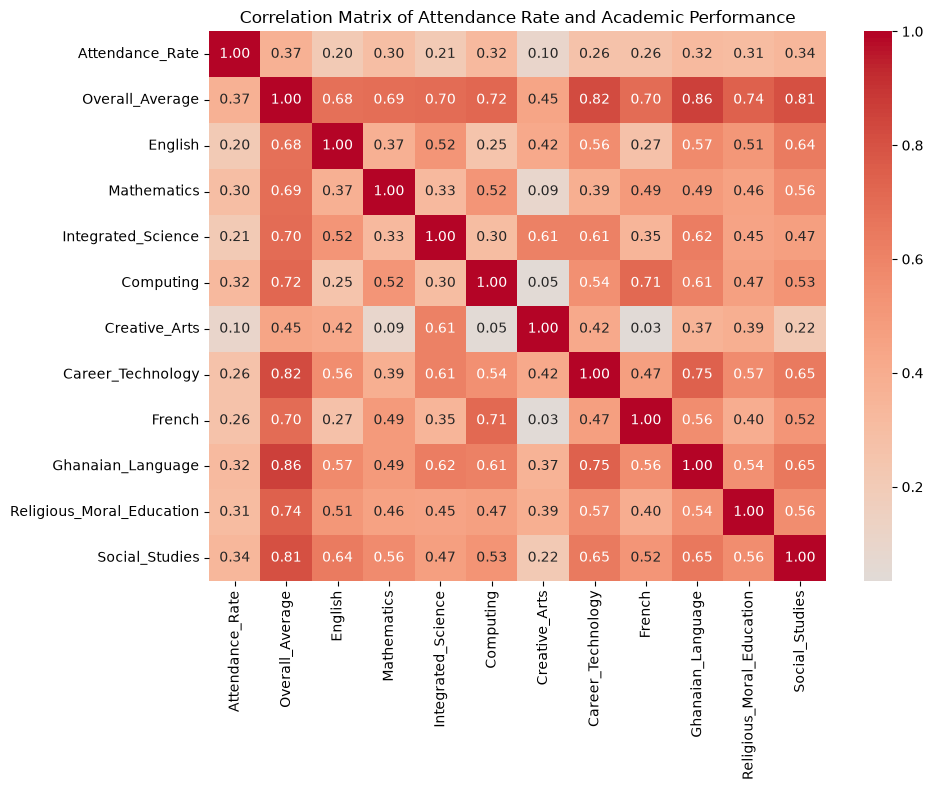

In [21]:
correlation_data = attendance.merge(
    performance,
    on=["Student_ID", "Student_Name", "Term_ID", "Term_Name"]
)

correlation_matrix = correlation_data[
    [
        "Attendance_Rate",
        "Overall_Average",
        "English",
        "Mathematics",
        "Integrated_Science",
        "Computing",
        "Creative_Arts",
        "Career_Technology",
        "French",
        "Ghanaian_Language",
        "Religious_Moral_Education",
        "Social_Studies"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Attendance Rate and Academic Performance")

plt.tight_layout()
plt.show()

## Interpretation

The correlation matrix shows that **attendance rate has a positive relationship with overall academic performance (r = 0.37)**. While this relationship is moderate rather than strong, it suggests that students with higher attendance generally tend to achieve better academic results.

Attendance also exhibits weak to moderate positive correlations with the individual subjects, ranging from **0.10** for Creative Arts to **0.34** for Social Studies. This indicates that regular attendance contributes to improved performance across subjects, although other factors also influence students' academic achievement.

As expected, the **Overall Average** has strong positive correlations with all individual subjects because it is derived from these subject scores. The strongest relationships are observed with **Ghanaian Language (0.86)**, **Career Technology (0.82)**, and **Social Studies (0.81)**, suggesting that performance in these subjects closely reflects students' overall academic achievement.

Overall, the results indicate that maintaining good attendance is associated with better academic performance, but attendance alone does not fully explain differences in student outcomes. Additional factors beyond classroom attendance are likely to influence students' academic success.

## Relationship Between Attendance Rate and Academic Performance

This scatter plot visualizes the relationship between students' attendance rates and their overall academic performance. A regression line is added to highlight the general trend and assess whether higher attendance is associated with improved academic achievement.

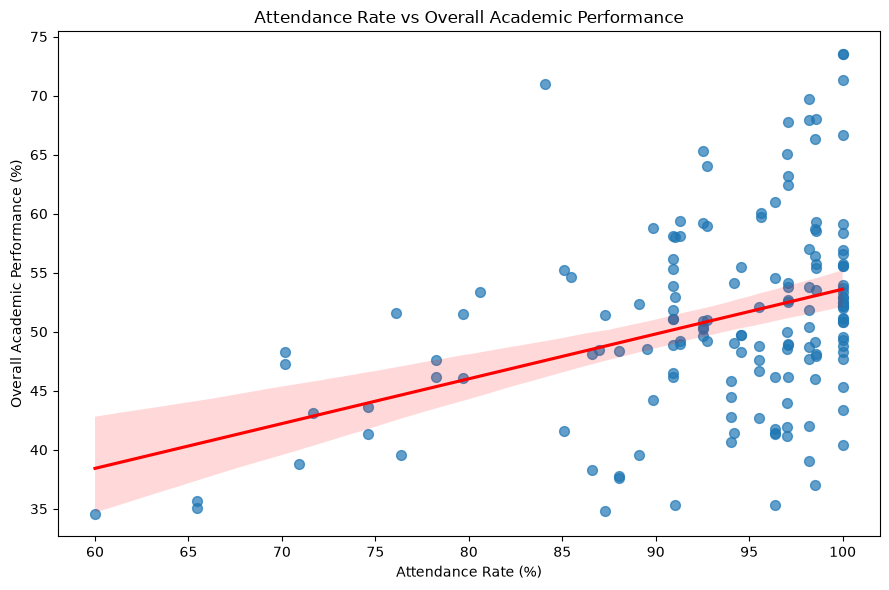

In [22]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=correlation_data,
    x="Attendance_Rate",
    y="Overall_Average",
    scatter_kws={
        "alpha":0.7,
        "s":50
    },
    line_kws={
        "color":"red"
    }
)

plt.title("Attendance Rate vs Overall Academic Performance")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Overall Academic Performance (%)")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows a positive relationship between attendance rate and overall academic performance, as indicated by the upward-sloping regression line. Students with higher attendance generally tend to achieve better academic results, supporting the moderate positive correlation identified in the previous analysis.

However, the data points are widely dispersed, particularly among students with attendance rates above 90%. While many students maintained excellent attendance, their academic performance still varied considerably, ranging from below 40% to above 70%. This suggests that although regular attendance supports academic achievement, additional factors such as study habits, learning ability, motivation, and classroom engagement also influence student performance.

Overall, the visualization confirms that attendance is an important contributor to academic success but should be considered alongside other factors when evaluating student achievement.

## Academic Performance by Attendance Category

This chart compares the average overall academic performance of students grouped by attendance category. It helps determine whether higher attendance levels are associated with better academic outcomes.

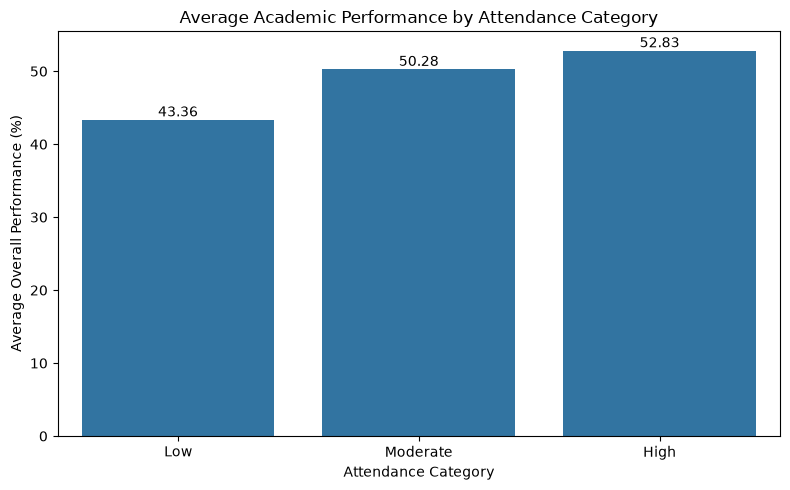

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=correlation_data,
    x="Attendance_Category",
    y="Overall_Average",
    estimator="mean",
    errorbar=None,
    order=["Low", "Moderate", "High"]
)

ax = plt.gca()

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Academic Performance by Attendance Category")
plt.xlabel("Attendance Category")
plt.ylabel("Average Overall Performance (%)")

plt.tight_layout()
plt.show()

## Interpretation

The chart shows a clear positive relationship between attendance rate and students' average academic performance. Students in the **High Attendance** category achieved the highest average overall score (**52.83%**), followed by those with **Moderate Attendance** (**50.28%**). Students with **Low Attendance** recorded the lowest average performance (**43.36%**).

Although the improvement in performance from the Moderate to High attendance categories is relatively small, there is a substantial difference between students with low attendance and the other two groups. This suggests that maintaining a reasonable level of attendance is associated with better academic outcomes, while very poor attendance is linked to noticeably lower achievement.

Overall, the findings reinforce the earlier correlation analysis, indicating that attendance contributes positively to academic performance but is not the sole factor influencing students' overall achievement. Other academic and contextual factors are also likely to play important roles.

## Attendance Rate by Academic Term

This visualization compares the average attendance rate across the three academic terms. Since attendance has been converted to percentages based on the total instructional days in each term, the comparison provides a fair assessment of student attendance throughout the academic year.

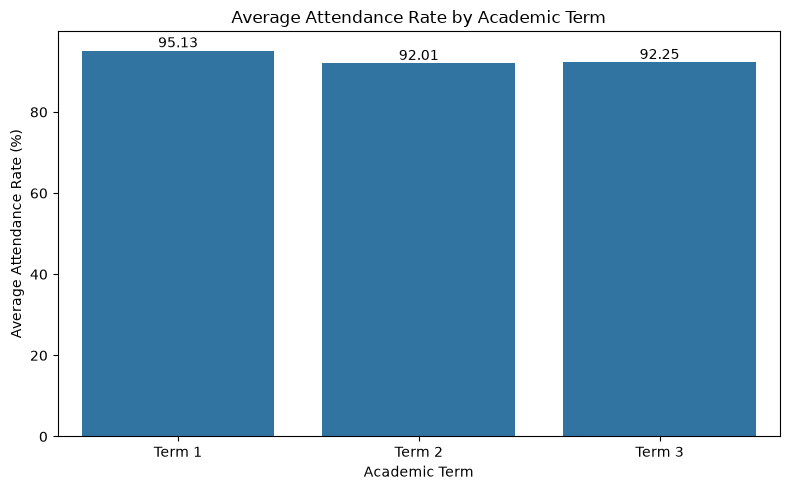

In [26]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=attendance,
    x="Term_Name",
    y="Attendance_Rate",
    estimator="mean",
    errorbar=None,
    order=["Term 1", "Term 2", "Term 3"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Attendance Rate by Academic Term")
plt.xlabel("Academic Term")
plt.ylabel("Average Attendance Rate (%)")

plt.tight_layout()
plt.show()

### Interpretation

The average attendance rate remained consistently high throughout the academic year, exceeding 92% in all three terms. Students recorded the highest attendance rate in **Term 1 (95.13%)**, followed by **Term 3 (92.25%)** and **Term 2 (92.01%)**. The relatively small differences between terms indicate that student attendance remained stable after accounting for the varying number of instructional days in each term.

Given the consistently high attendance rates across the academic year, the decline in overall academic performance observed after Term 1 is unlikely to be explained solely by reduced attendance. This suggests that additional academic or instructional factors may have contributed to changes in student performance.

## Top Performing Students

This chart highlights the highest-performing students based on their overall academic average. Identifying exceptional performers provides insight into the highest level of academic achievement attained during the academic year.

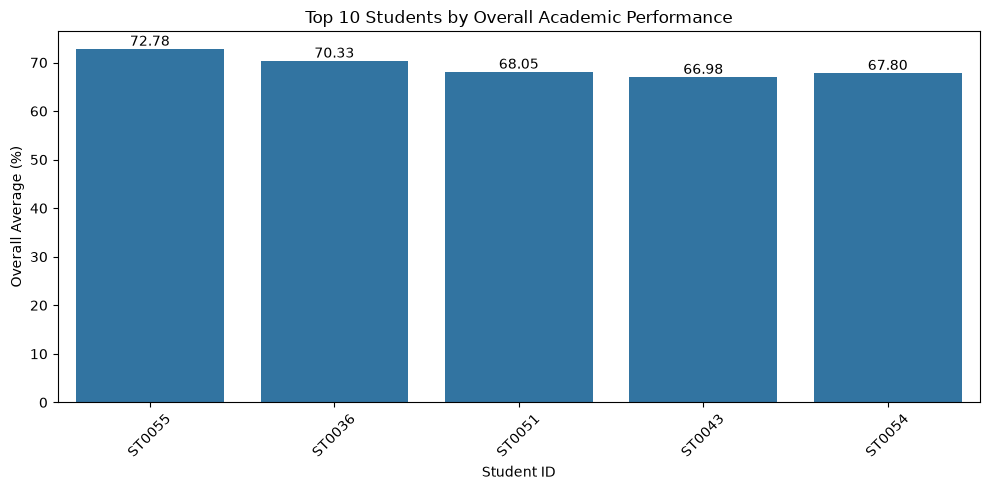

In [27]:
top_students = (
    performance
    .sort_values("Overall_Average", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_students,
    x="Student_ID",
    y="Overall_Average",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Top 10 Students by Overall Academic Performance")
plt.xlabel("Student ID")
plt.ylabel("Overall Average (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The chart highlights the highest-performing students based on their overall academic averages. The leading student achieved an overall average of approximately **72.78%**, while the remaining top-performing students recorded averages between **66% and 70%**.

The relatively small differences among the highest-performing students indicate a competitive group of high achievers. These students may serve as useful benchmarks for identifying effective learning strategies and recognizing academic excellence within the school.

## Correlation with Overall Academic Performance

This visualization ranks the relationship between attendance and each academic subject with students' overall academic performance. Higher correlation values indicate stronger positive relationships with overall achievement.

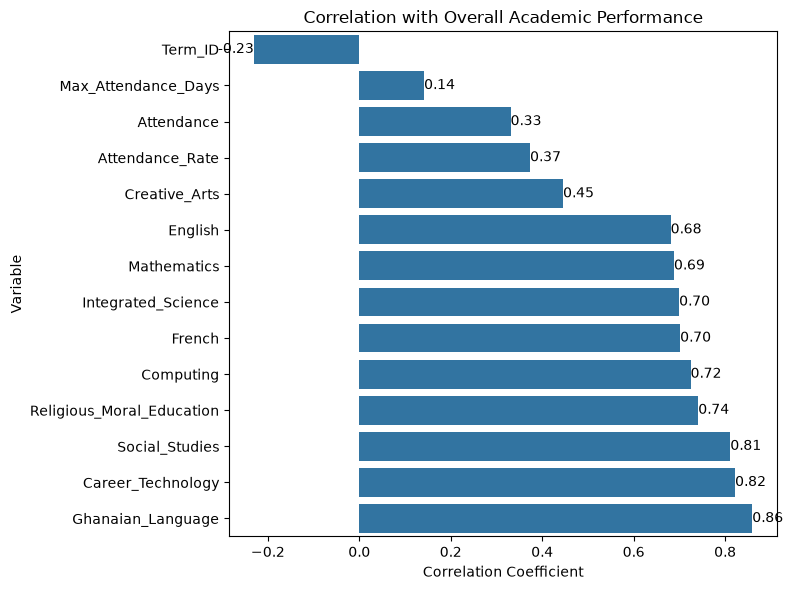

In [28]:
corr = correlation_data.corr(numeric_only=True)["Overall_Average"]

corr = (
    corr
    .drop("Overall_Average")
    .sort_values()
)

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=corr.values,
    y=corr.index
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Correlation with Overall Academic Performance")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis shows that **Attendance Rate** has a **moderate positive relationship (r = 0.37)** with overall academic performance. While higher attendance is generally associated with better academic outcomes, its influence is considerably weaker than the relationships observed for individual subject scores.

Among the academic subjects, **Ghanaian Language (r = 0.86)**, **Career Technology (r = 0.82)** and **Social Studies (r = 0.81)** exhibited the strongest positive correlations with overall academic performance. Mathematics and English also showed strong positive relationships, although their correlations were comparatively lower.

Overall, the findings suggest that student achievement across individual subjects contributes more strongly to overall academic performance than attendance alone. Attendance remains an important supporting factor but is not the primary determinant of students' academic success.